---



---

# **JOBSHEET 5 - MENGUKUR KEMIRIPAN CITRA**
##***Penugasan Nomor 3 dan 4***



---

---
NAMA : Muhammad Eka Sobirin

NIM : 3.34.23.2.14

Mata Kuliah : Pengolahan Citra

Dosen Pengampu : Ir. Prayitno, S.ST., M.T., Ph.D.



---



---


##**PENUGASAN NOMOR 3**
---
Fitur Berbeda untuk CBIR: Modifikasi Praktikum 5. Alih-alih menggunakan histogram warna, coba gunakan fitur yang lebih sederhana seperti rata-rata warna (mean R, mean, G mean B) sebagai vektor fitur 3 dimensi. Hitung kemiripan menggunakan Jarak
Euclidean (L_2) antara vektor fitur rata-rata warna ini. Bandingkan hasil retrievalnya dengan hasil yang menggunakan histogram. Manakah fitur yang lebih baik untuk membedakan citra-citra dalam database kecil tersebut?


Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval Berdasarkan Mean RGB:
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


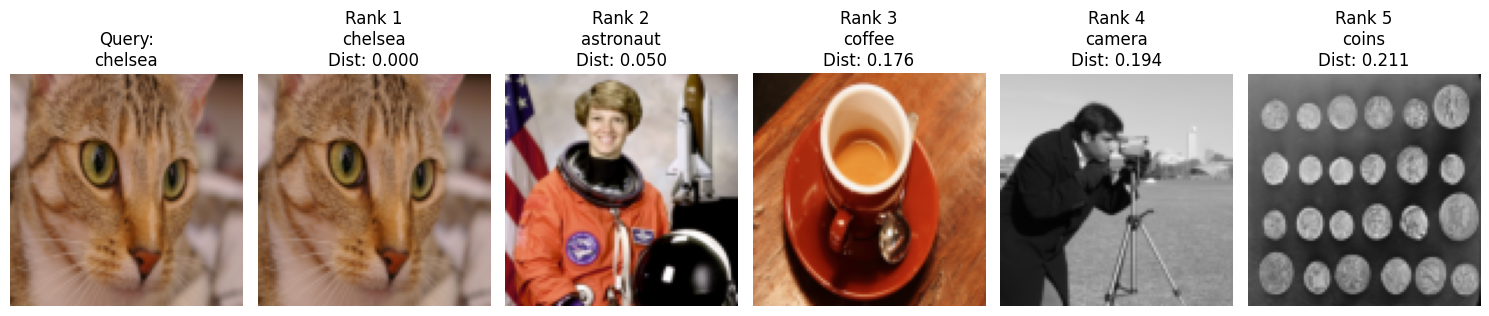

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, transform
from scipy.spatial import distance


# =========================================================
# Fungsi menghitung mean RGB
# =========================================================

def calculate_mean_rgb(image):

    # Menghitung rata-rata tiap channel warna
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    # Menggabungkan menjadi vektor fitur
    mean_vector = np.array([mean_r, mean_g, mean_b])

    return mean_vector


# =========================================================
# 1. Menyiapkan database citra
# =========================================================

image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_features = []

print("Memproses database citra...")

for name in image_db_names:

    try:
        # Memuat citra
        img = getattr(data, name)()

        # Jika grayscale, ubah menjadi RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize citra
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan citra
        database_images.append(img_resized)

        # Hitung fitur mean RGB
        feature = calculate_mean_rgb(img_resized)

        database_features.append(feature)

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# =========================================================
# 2. Menentukan citra query
# =========================================================

query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_feature = database_features[query_index]


# =========================================================
# 3. Menghitung jarak Euclidean
# =========================================================

distances = []

for feature in database_features:

    dist = distance.euclidean(query_feature, feature)

    distances.append(dist)


# =========================================================
# 4. Mengurutkan hasil retrieval
# =========================================================

sorted_indices = np.argsort(distances)


# =========================================================
# 5. Menampilkan hasil retrieval
# =========================================================

num_results = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results + 1,
    figsize=(15, 3)
)

# Menampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval Berdasarkan Mean RGB:")

# Menampilkan hasil ranking
for i, idx in enumerate(sorted_indices):

    rank = i + 1

    axes[rank].imshow(database_images[idx])

    axes[rank].set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    axes[rank].axis('off')

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )

plt.tight_layout()
plt.show()

##**PENUGASAN NOMOR 4**
---
Template Matching Invariant: Cari tahu dari dokumentasi skimage.feature.match_template atau sumber lain, apakah metode match_template
standar invariant terhadap rotasi atau perubahan skala? Jelaskan. (Petunjuk: Coba rotasi atau ubah ukuran template pada Praktikum 4 dan lihat hasilnya).

Skor Matching Template Asli    : 1.0000
Skor Matching Template Rotasi : 0.6059
Skor Matching Template Skala  : 0.5654


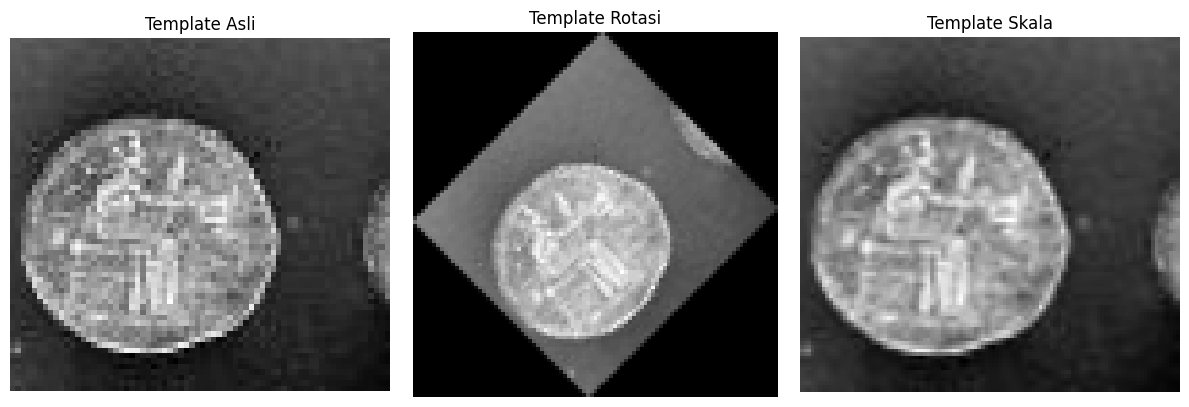

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, transform
from skimage.feature import match_template


# =========================================================
# 1. Memuat citra dan template asli
# =========================================================

image = data.coins()

# Template asli
template = image[15:80, 190:260]


# =========================================================
# 2. Membuat template hasil rotasi dan perubahan skala
# =========================================================

# Template diputar 45 derajat
template_rotated = transform.rotate(
    template,
    angle=45,
    resize=True
)

# Template diperbesar
template_scaled = transform.rescale(
    template,
    scale=1.5,
    anti_aliasing=True
)


# =========================================================
# 3. Melakukan template matching
# =========================================================

# Matching template asli
result_original = match_template(image, template)

# Matching template rotasi
result_rotated = match_template(image, template_rotated)

# Matching template skala
result_scaled = match_template(image, template_scaled)


# =========================================================
# 4. Mengambil nilai kecocokan tertinggi
# =========================================================

max_original = np.max(result_original)
max_rotated = np.max(result_rotated)
max_scaled = np.max(result_scaled)


# =========================================================
# 5. Menampilkan hasil
# =========================================================

print(f"Skor Matching Template Asli    : {max_original:.4f}")
print(f"Skor Matching Template Rotasi : {max_rotated:.4f}")
print(f"Skor Matching Template Skala  : {max_scaled:.4f}")


# =========================================================
# 6. Visualisasi template
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(template, cmap='gray')
axes[0].set_title('Template Asli')
axes[0].axis('off')

axes[1].imshow(template_rotated, cmap='gray')
axes[1].set_title('Template Rotasi')
axes[1].axis('off')

axes[2].imshow(template_scaled, cmap='gray')
axes[2].set_title('Template Skala')
axes[2].axis('off')

plt.tight_layout()
plt.show()